<a href="https://colab.research.google.com/github/fiona-crdt/2026_Intro_Python/blob/main/live/part-I/1.5-pandas-environmental-exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> Notebook-friendly copy of `part-I/1.5-pandas-environmental-exercises.ipynb`, generated by `tools/make_live.py`. Edit the book notebook, not this file.

In [1]:
# --- environment setup (generated, not part of the lesson) ---
# Colab and Kaggle do not ship every package this notebook imports.
# This is a no-op in an environment that is already set up.
import importlib.util
import subprocess
import sys

for module, package in {"pooch": "pooch"}.items():
    if importlib.util.find_spec(module) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", package], check=True)

# Environmental Exercises

**ℹ️ How to use these exercises**

Attempt each from scratch in the empty code cell. Import pandas as `pd` and numpy as `np`, seed any randomness with `default_rng`, and keep units in your column names.

## Exercise 1: Earthquake data analysis

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/usgs-2014-south-napa-earthquake.jpg" alt="A dirt track through a vineyard, broken along its length by a continuous ridge of pushed-up soil following the fault trace" width="800">

<em>Surface rupture from the magnitude 6.0 South Napa earthquake of 24 August 2014 — the kind of event a row in this catalog stands for. The continuous "mole track" running parallel to the strike of the fault indicates some east–west compression on top of the <a href="https://www.usgs.gov/faqs/what-fault-and-what-are-different-types">right-lateral faulting</a>; taken near Buhman Road. Photo <a href="https://www.usgs.gov/media/images/2014-south-napa-ca-m6-earthquake-august-24-6">USGS</a>, public domain.</em>


This exercise reviews the `pandas` fundamentals of this subchapter on one real catalog, covering how to

* open csv files
* manipulate dataframe indexes
* parse date columns
* examine basic dataframe statistics
* manipulate text columns and extract values
* plot dataframe contents using
  * bar charts
  * histograms
  * scatter plots

The data is a snapshot of the [USGS Earthquakes Database](https://earthquake.usgs.gov/earthquakes/search/): every event recorded worldwide in 2014, 120 108 rows.

You do not need to download the file yourself. The pre-supplied cell below fetches and caches it with the help of [pooch](https://www.fatiando.org/pooch/latest/) — there is no need to read pooch's documentation unless you want to — and stores the path to the file in the variable `datafile`.

In [2]:
# Pre-supplied: download and cache the earthquake data.
import pooch

datafile = pooch.retrieve(
    url="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/usgs_earthquakes_2014.csv",
    known_hash="sha256:84d455fb96dc8f782fba4b5fbe56cb8970cab678f07c766fcba1b1c4674de1b1",
    fname="usgs_earthquakes_2014.csv",
    path=pooch.os_cache("mlees"),
)

**ℹ️ Beyond this subchapter**

The tools below were not demonstrated in 1.5's lecture. Each question links its documentation where
it is needed; they are collected here so you know when you are being asked to read a new page rather
than to recall one:

- [`nlargest`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.nlargest.html) — Q5
- [pandas' text data functions](https://pandas.pydata.org/pandas-docs/stable/user_guide/text.html), and [`Series.str.split`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.str.split.html) in particular — Q6
- [`unique`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.unique.html) — Q7
- [`count`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.count.html) and [`value_counts`](https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html) — Q9

The scatter plot and colorbar in Q11 are the ones from 1.4.6. Everything else the questions ask for
is from this subchapter's lecture: `read_csv` with date-parsed columns, `set_index`, `.head()`,
`.info()`, `.describe()`, boolean filtering, `.index` and `.values`, `kind="bar"`, `kind="hist"`, and
a logarithmic count axis.

**Q1) First, import `numpy`, `pandas` and `matplotlib`, and — optionally — set the display options.**

Hint: display options are documented [at this link](https://pandas.pydata.org/pandas-docs/stable/user_guide/options.html).

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Q2) Use pandas' `read_csv` function directly on `datafile` to open it as a `DataFrame`.**

Display the first few rows with `.head()`, and the column names, dtypes and non-null counts with
`.info()`. Check these tutorials if you have doubts about what the two functions do:
[`.head()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.head.html)
and
[`.info()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.info.html?highlight=info#pandas.DataFrame.info).

`.info()` will show you that the two date columns, `time` and `updated`, came in as plain strings
rather than as dates. They were not parsed automatically. What can you do about that?

In [4]:
# Open the file as a pandas DataFrame, then display the first few rows and the DataFrame info
df = pd.read_csv(datafile)
df.head()
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120108 entries, 0 to 120107
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   time       120108 non-null  object 
 1   latitude   120108 non-null  float64
 2   longitude  120108 non-null  float64
 3   depth      120107 non-null  float64
 4   mag        120065 non-null  float64
 5   magType    120065 non-null  object 
 6   nst        59688 non-null   float64
 7   gap        94935 non-null   float64
 8   dmin       85682 non-null   float64
 9   rms        119716 non-null  float64
 10  net        120108 non-null  object 
 11  id         120108 non-null  object 
 12  updated    120108 non-null  object 
 13  place      120108 non-null  object 
 14  type       120108 non-null  object 
dtypes: float64(8), object(7)
memory usage: 13.7+ MB


**Q3) Re-read the data in such a way that both date columns are identified as dates and the earthquake ID is used as the index.**

Check with `.head()` and `.info()` that it worked: `time` and `updated` should now be
`datetime64` columns, and `id` should be the index rather than a column.

Hint: the documentation for `read_csv` is [here](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html?highlight=read_csv).

In [5]:
# Re-read the file, then check with head and info that it worked
df = pd.read_csv(datafile, parse_dates=["time", "updated"], index_col="id")
df.head()


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,updated,place,type
id,,,,,,,,,,,,,,
ak11155107,2014-01-31 23:53:37.000,60.252000,-152.7081,90.20,1.10,ml,NaN,NaN,NaN,0.2900,ak,2014-02-05 19:34:41.515000+00:00,"26km S of Redoubt Volcano, Alaska",earthquake
nn00436847,2014-01-31 23:48:35.452,37.070300,-115.1309,0.00,1.33,ml,4.0,171.43,0.34200,0.0247,nn,2014-02-01 01:35:09+00:00,"32km S of Alamo, Nevada",earthquake
ak11151142,2014-01-31 23:47:24.000,64.671700,-149.2528,7.10,1.30,ml,NaN,NaN,NaN,1.0000,ak,2014-02-01 00:03:53.010000+00:00,"12km NNW of North Nenana, Alaska",earthquake
ak11151135,2014-01-31 23:30:54.000,63.188700,-148.9575,96.50,0.80,ml,NaN,NaN,NaN,1.0700,ak,2014-01-31 23:41:25.007000+00:00,"22km S of Cantwell, Alaska",earthquake
ci37171541,2014-01-31 23:30:52.210,32.616833,-115.6925,10.59,1.34,ml,6.0,285.00,0.04321,0.2000,ci,2014-02-01 00:13:20.107000+00:00,"10km WNW of Progreso, Mexico",earthquake


**Q4) Use `describe` to get the basic statistics of all the columns.**

Hint: the documentation of `describe` is [at this link](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html).

In [6]:
# Use the describe function
df.describe()

,time,latitude,longitude,depth,mag,nst,gap,dmin,rms
count,120108,120108.000000,120108.000000,120107.000000,120065.000000,59688.000000,94935.000000,85682.000000,119716.000000
mean,2014-07-05 09:10:37.116720128,38.399579,-99.961402,28.375029,1.793958,17.878284,124.048978,0.893198,0.358174
min,2014-01-01 00:01:16.610000,-73.462000,-179.998900,-9.900000,-0.970000,0.000000,9.000000,0.000000,0.000000
25%,2014-04-08 03:43:10.768999936,34.228917,-147.742025,4.100000,0.820000,8.000000,74.000000,0.020760,0.070000
50%,2014-07-07 10:44:06.035000064,38.805300,-120.832000,9.200000,1.400000,14.000000,107.000000,0.073670,0.200000
75%,2014-09-30 23:36:40.595000064,53.889500,-116.068100,22.880000,2.400000,22.000000,155.000000,0.447000,0.590000
max,2014-12-31 23:54:33.900000,86.651400,179.998000,697.360000,8.200000,365.000000,356.400000,64.498000,8.460000
std,NaN,21.938258,82.996858,62.215416,1.343466,14.911369,68.518595,2.903966,0.364046


**Q5) Use `nlargest` to get the top 20 earthquakes by magnitude.**

Hint: the documentation of `nlargest` is [at this link](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.nlargest.html).

In [7]:
# Use nlargest
df.mag.nlargest(20)

,mag
id,
usc000nzvd,8.2
usc000rki5,7.9
usc000p27i,7.7
usc000phx5,7.6
usb000pr89,7.5
usc000piqj,7.4
usb000slwn,7.3
usb000pq41,7.2
usc000pft9,7.1


**Q6) Extract the state or country using pandas' text data functions, and add it as a new column to the `DataFrame`.**

Examine the column titled `place`: it holds strings like `"26km S of Redoubt Volcano, Alaska"`, so
it carries both the local description and the state or country. Pull the second part out and store
it in a new column called `country`.

Hint 1: the documentation for pandas' text data functions is [here](https://pandas.pydata.org/pandas-docs/stable/text.html).

Hint 2: you will use `.split()` to extract the country names. The documentation of this function
can be found [here](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.str.split.html?highlight=split#pandas.Series.str.split).

In [8]:
# Extract the state or country, and add it as a new column to the DataFrame called country
df["country"] = df["place"].str.split(",").str[-1]

**Q7) Display each unique value from the new `country` column.**

Hint: you may use the `unique` function documented [at this link](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.unique.html).

You should see an array of a couple of hundred country and state names. A plain split leaves the
space that followed the comma, so they come out as `array([' Alaska', ' Nevada', ...])` — worth
removing before you use them as labels.

In [9]:
# Display unique values
df["country"].unique()

array([' Alaska', ' Nevada', ' Mexico', ' California',
       ' Papua New Guinea', ' New Zealand', ' Missouri',
       'South of the Fiji Islands', ' Montana', ' British Virgin Islands',
       ' Washington', ' Oregon', ' Canada', ' Fiji', 'Wyoming',
       ' Antarctica', ' Chile', ' Utah', ' Indonesia', ' Solomon Islands',
       ' Micronesia', ' Oklahoma', ' Hawaii', ' Wyoming', ' Russia',
       ' Arizona', ' Philippines', ' Bolivia', ' Greece', ' Japan',
       ' Puerto Rico', ' Iran', ' Tonga', ' Wallis and Futuna',
       ' Colorado', ' Guam', ' CA', 'Carlsberg Ridge', ' Idaho',
       ' Pakistan', 'Off the west coast of northern Sumatra', ' Burma',
       ' China', ' Peru',
       'Off the east coast of the North Island of New Zealand',
       ' Costa Rica', 'Reykjanes Ridge', ' East Timor',
       'Central East Pacific Rise', 'Mid-Indian Ridge', ' Japan region',
       ' Northern Mariana Islands', ' El Salvador', ' Samoa',
       'Northern Mid-Atlantic Ridge', ' Taiwan', ' Arka

**Q8) Create a filtered dataset that only has earthquakes larger than magnitude 4.**

Hint: print the table to see the name of the column containing the earthquake magnitude.

Check out this [link](https://www.geeksforgeeks.org/ways-to-filter-pandas-dataframe-by-column-values/)
to find examples of filtering by column values.

In [10]:
# Filter the dataset based on the earthquakes' magnitudes
df_filtered = df[(df["mag"]>4)]

**Q9) Using the filtered dataset (magnitude > 4), count the number of earthquakes whose magnitudes are above 4 [Num 1], and count the number of earthquakes in each country or state [Num 2]. Make a bar chart of Num 2 for the top 5 locations with the most earthquakes.**

Hint 1: to get Num 1, pandas has a `count` function documented
[at this link](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.count.html).

Hint 2: check out the
[`value_counts`](https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html)
function to get Num 2.

Then convert the first five rows of Num 2 into a `DataFrame` with two columns, `country` (text)
and `earthquake_num` (number), and recreate the bar chart below.

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/1.5-target-top5-bar.png" alt="A bar chart of the number of magnitude-above-4 earthquakes in the five countries with the most of them" width="700">

<em>The five locations with the most magnitude-above-4 events in 2014.</em>

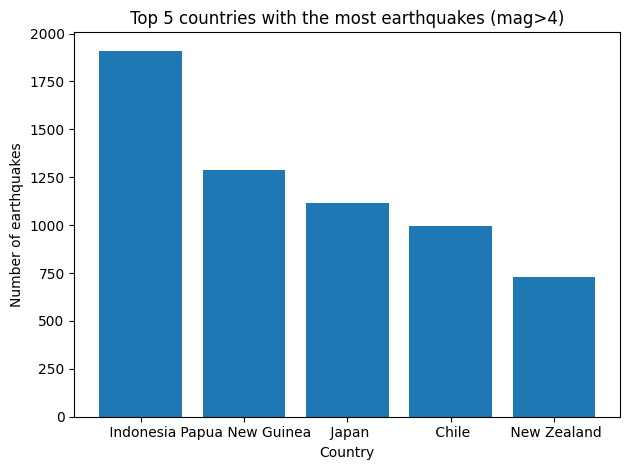

In [11]:
# Count the >4 earthquakes, count them per country, then plot the top 5 as a bar chart
Num1 = df_filtered.count()
Num2 = df_filtered["country"].value_counts()
Num2 = Num2.head(5)
Num2 = pd.DataFrame({"country": Num2.index, "earthquake_num": Num2.values})
plt.bar(Num2["country"], Num2["earthquake_num"])
plt.xlabel("Country")
plt.ylabel("Number of earthquakes")
plt.title("Top 5 countries with the most earthquakes (mag>4)")
plt.tight_layout()
plt.show()

**Q10) Make a histogram for the distribution of the earthquakes' magnitudes.**

Hint: pandas has a histogram function documented
[at this link](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.hist.html) and
matplotlib has one documented
[at this link](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.hist.html).

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/1.5-target-magnitude-hist.png" alt="A histogram of earthquake magnitude with a dashed grid" width="700">

<em>The distribution of magnitude across the whole catalog.</em>


Then redraw it with a logarithmic scale on the y-axis, which brings the rare large events into
view alongside the many small ones. Hint: here you can find a
[tutorial](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.yscale.html) for how to
change an axis scale.

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/1.5-target-magnitude-hist-log.png" alt="The same histogram of earthquake magnitude with a logarithmic y-axis" width="700">

<em>The same histogram with a logarithmic count axis.</em>


Finally, make one histogram for the filtered dataset and one for the unfiltered dataset, side by
side.

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/1.5-target-hist-filtered-unfiltered.png" alt="Two histograms of earthquake magnitude side by side, one for events above magnitude 4 and one for the whole catalog" width="100%">

<em>The filtered and unfiltered magnitude distributions, drawn on their own count axes.</em>

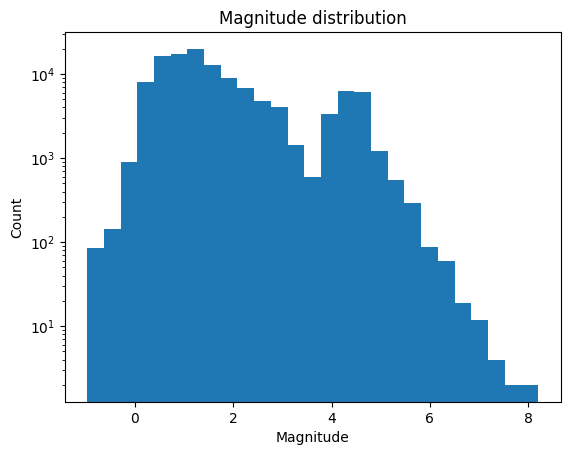

AttributeError: 'numpy.ndarray' object has no attribute 'set_xlabel'

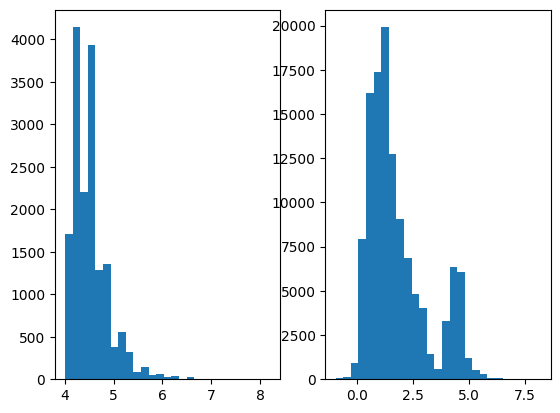

In [17]:
# Make the three histograms

fig, ax = plt.subplots()
ax.hist(df["mag"], bins=27, log=True)
ax.set_xlabel("Magnitude")
ax.set_ylabel("Count")
ax.set_title("Magnitude distribution")
plt.show()

fig, ax = plt.subplots(1,2)
ax[0].hist(df_filtered["mag"], bins=27)
ax[1].hist(df["mag"], bins=27)
ax.set_xlabel("Magnitude")
ax.set_ylabel("Count")
ax.set_title("Magnitude distribution")
plt.show()

**Q11) Visualise the locations of earthquakes by making a scatterplot of their latitude and longitude.**

Make a figure with two panels: one for the filtered dataset and one for the unfiltered one, with
the points coloured by magnitude on a shared colour range.

Hint: consider reading the documentation for
[`plt.scatter`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) to make
the scatter plot and that of
[`plt.colorbar`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.colorbar.html) to
colour the points by magnitude. Pass the same `vmin` and `vmax` to both scatter calls, so that a
colour stands for the same magnitude in both panels.

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/1.5-target-quake-scatter.png" alt="Two scatter plots of earthquake longitude against latitude coloured by magnitude, one filtered to magnitude above 4 and one unfiltered" width="100%">

<em>Every event in the catalog placed by longitude and latitude, filtered and unfiltered.</em>

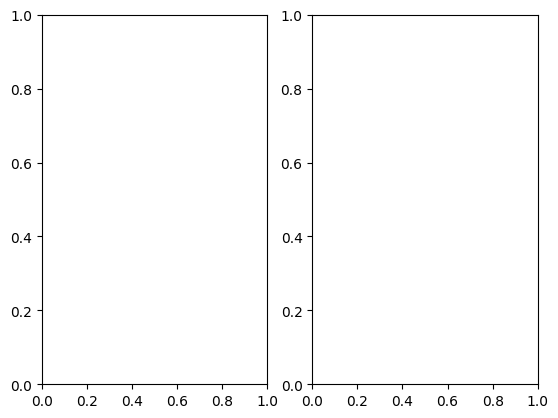

In [19]:
# Make the two scatter plots
fig, ax = plt.subplots(1,2)

Do you notice a difference between the filtered and unfiltered datasets?